In [2]:
from collections import defaultdict
import gymnasium as gym
import numpy as np
from tqdm import tqdm  # Progress bar

In [3]:


class BlackjackAgent:
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        """Initialize a Q-Learning agent.

        Args:
            env: The training environment
            learning_rate: How quickly to update Q-values (0-1)
            initial_epsilon: Starting exploration rate (usually 1.0)
            epsilon_decay: How much to reduce epsilon each episode
            final_epsilon: Minimum exploration rate (usually 0.1)
            discount_factor: How much to value future rewards (0-1)
        """
        self.env = env

        # Q-table: maps (state, action) to expected reward
        # defaultdict automatically creates entries with zeros for new states
        # Determine action space size in a type-safe way (handle Discrete and fallbacks)
        if isinstance(env.action_space, gym.spaces.Discrete):
            action_size = env.action_space.n
        else:
            shape = getattr(env.action_space, "shape", (1,))
            action_size = int(getattr(env.action_space, "n", shape[0]))
        self.q_values = defaultdict(lambda: np.zeros(action_size))

        self.lr = learning_rate
        self.discount_factor = discount_factor  # How much we care about future rewards

        # Exploration parameters
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        # Track learning progress
        self.training_error = []
        # Per-episode statistics
        self.episode_rewards = []
        self.episode_td_means = []

    def get_action(self, obs: tuple[int, int, bool]) -> int:
        """Choose an action using epsilon-greedy strategy.

        Returns:
            action: 0 (stand) or 1 (hit)
        """
        # With probability epsilon: explore (random action)
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()

        # With probability (1-epsilon): exploit (best known action)
        else:
            return int(np.argmax(self.q_values[obs]))

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Update Q-value based on experience.

        This is the heart of Q-learning: learn from (state, action, reward, next_state)
        """
        # What's the best we could do from the next state?
        # (Zero if episode terminated - no future rewards possible)
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])

        # What should the Q-value be? (Bellman equation)
        target = reward + self.discount_factor * future_q_value

        # How wrong was our current estimate?
        temporal_difference = target - self.q_values[obs][action]

        # Update our estimate in the direction of the error
        # Learning rate controls how big steps we take
        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )

        # Track learning progress (useful for debugging)
        self.training_error.append(temporal_difference)
        return temporal_difference

    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)


In [4]:

# Training hyperparameters
learning_rate = 0.01        # How fast to learn (higher = faster but less stable)
n_episodes = 100_000        # Number of hands to practice
start_epsilon = 1.0         # Start with 100% random actions
epsilon_decay = start_epsilon / (n_episodes / 2)  # Reduce exploration over time
final_epsilon = 0.1         # Always keep some exploration

# Create environment and agent
env = gym.make("Blackjack-v1", sab=False)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = BlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)


# Logging / evaluation settings
logging_interval = 1000
recent_avg_window = 100

rewards_history = []
td_history = []

for episode in tqdm(range(n_episodes)):
    # Start a new hand
    obs, info = env.reset()
    done = False

    # Per-episode accumulators
    episode_reward = 0.0
    episode_tds = []

    # Play one complete hand
    while not done:
        # Agent chooses action (initially random, gradually more intelligent)
        action = agent.get_action(obs)

        # Take action and observe result
        next_obs, reward, terminated, truncated, info = env.step(action)

        # Learn from this experience (update returns the TD error)
        td = agent.update(obs, action, float(reward), terminated, next_obs)
        episode_tds.append(td)

        # Accumulate episode reward
        episode_reward += float(reward)

        # Move to next state
        done = terminated or truncated
        obs = next_obs

    # Reduce exploration rate (agent becomes less random over time)
    agent.decay_epsilon()

    # Save per-episode stats
    agent.episode_rewards.append(episode_reward)
    mean_td = float(np.mean(episode_tds)) if len(episode_tds) > 0 else 0.0
    agent.episode_td_means.append(mean_td)

    rewards_history.append(episode_reward)
    td_history.append(mean_td)

    # Periodic logging to keep output manageable
    if (episode + 1) % logging_interval == 0 or (episode == n_episodes - 1):
        avg_recent_reward = (
            float(np.mean(rewards_history[-recent_avg_window:]))
            if len(rewards_history) > 0
            else 0.0
        )
        avg_recent_td = (
            float(np.mean(td_history[-recent_avg_window:])) if len(td_history) > 0 else 0.0
        )
        tqdm.write(
            f"Episode {episode+1}/{n_episodes} | avg_reward({recent_avg_window})={avg_recent_reward:.4f} | avg_td({recent_avg_window})={avg_recent_td:.6f} | eps={agent.epsilon:.4f}"
        )



  2%|▏         | 1852/100000 [00:00<00:25, 3817.56it/s]

Episode 1000/100000 | avg_reward(100)=-0.4700 | avg_td(100)=-0.309619 | eps=0.9800


  2%|▏         | 2234/100000 [00:00<00:28, 3490.64it/s]

Episode 2000/100000 | avg_reward(100)=-0.3900 | avg_td(100)=-0.298852 | eps=0.9600


  4%|▍         | 3880/100000 [00:01<00:25, 3781.21it/s]

...

Episode 98000/100000 | avg_reward(100)=-0.1200 | avg_td(100)=-0.021688 | eps=0.1000


 99%|█████████▉| 99446/100000 [00:24<00:00, 4349.02it/s]

Episode 99000/100000 | avg_reward(100)=-0.0800 | avg_td(100)=-0.035289 | eps=0.1000


100%|██████████| 100000/100000 [00:24<00:00, 4140.46it/s]

Episode 100000/100000 | avg_reward(100)=-0.2300 | avg_td(100)=-0.107717 | eps=0.1000


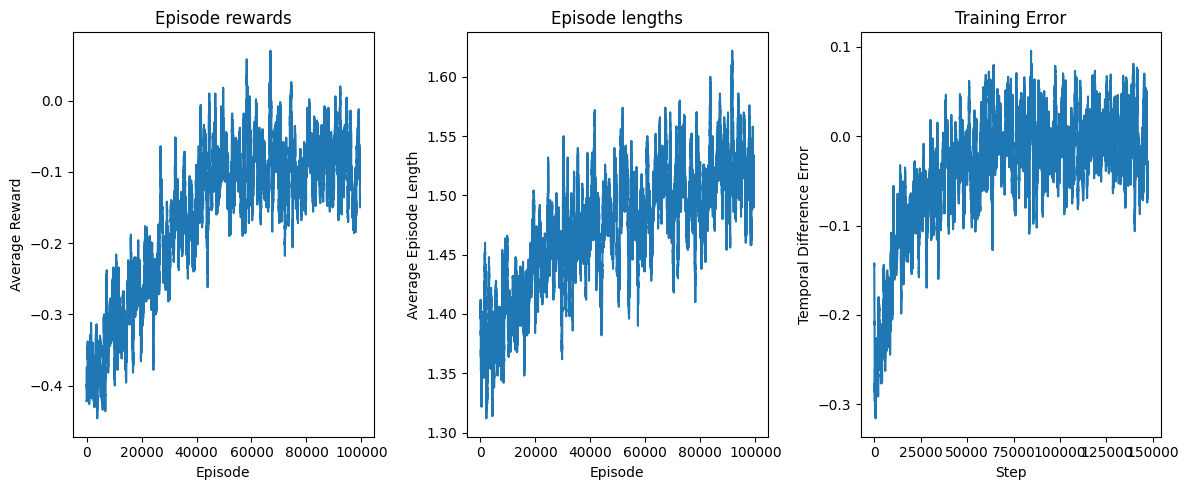

In [5]:
from matplotlib import pyplot as plt

def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [6]:
# Test the trained agent
def test_agent(agent, env, num_episodes=1000):
    """Test agent performance without learning or exploration."""
    total_rewards = []

    # Temporarily disable exploration for testing
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0  # Pure exploitation

    for _ in range(num_episodes):
        obs, info = env.reset()
        episode_reward = 0
        done = False

        while not done:
            action = agent.get_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated

        total_rewards.append(episode_reward)

    # Restore original epsilon
    agent.epsilon = old_epsilon

    win_rate = np.mean(np.array(total_rewards) > 0)
    average_reward = np.mean(total_rewards)

    print(f"Test Results over {num_episodes} episodes:")
    print(f"Win Rate: {win_rate:.1%}")
    print(f"Average Reward: {average_reward:.3f}")
    print(f"Standard Deviation: {np.std(total_rewards):.3f}")

# Test your agent
test_agent(agent, env)

Test Results over 1000 episodes:
Win Rate: 44.8%
Average Reward: -0.004
Standard Deviation: 0.949
